<a href="https://colab.research.google.com/github/amallindask/data-science-2026/blob/main/Pertemuan4_Amallinda_250401020003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IDENTITAS MAHASISWA**

---

Nama : AMallinda Sekar Kinasih

---

NIM : 250401020003

---
Kelas : IF403


**Statistika Dasar & Analisis Data**

In [1]:
# 1. Load & Inspect Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\nTipe Data:')
print(df.dtypes)
print('\nData Teratas:')
print(df.head())
print('\nDeskripsi Statistik:')
print(df.describe().round(3))

Shape: (150, 5)

Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Data Teratas:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Deskripsi Statistik:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.3

In [2]:
# 2. Statistik Deskriptif Lengkap
# Mengitung mean, median, std, varians, skewness, kurtosis untuk setiap kolom numerik.
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Skewness : {col.skew():.3f}')
    print(f'  Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Skewness : 0.315
  Kurtosis : -0.552

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Skewness : 0.319
  Kurtosis : 0.228

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Skewness : -0.275
  Kurtosis : -1.402

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Skewness : -0.103
  Kurtosis : -1.341


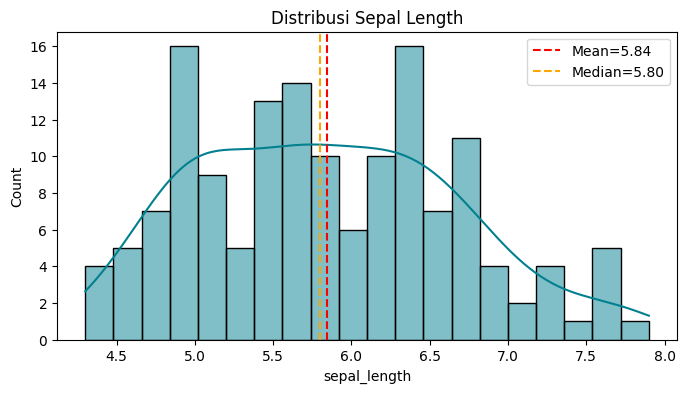

In [3]:
# 3. Analisis Distribusi (Histogram + KDE)
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df['sepal_length'],
             kde=True,
             color='#028090',
             bins=20, ax=ax)

ax.axvline(df['sepal_length'].mean(),
           color='red',
           linestyle='--',
           label=f"Mean={df['sepal_length'].mean():.2f}")

ax.axvline(df['sepal_length'].median(),
           color='orange',
           linestyle='--',
           label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

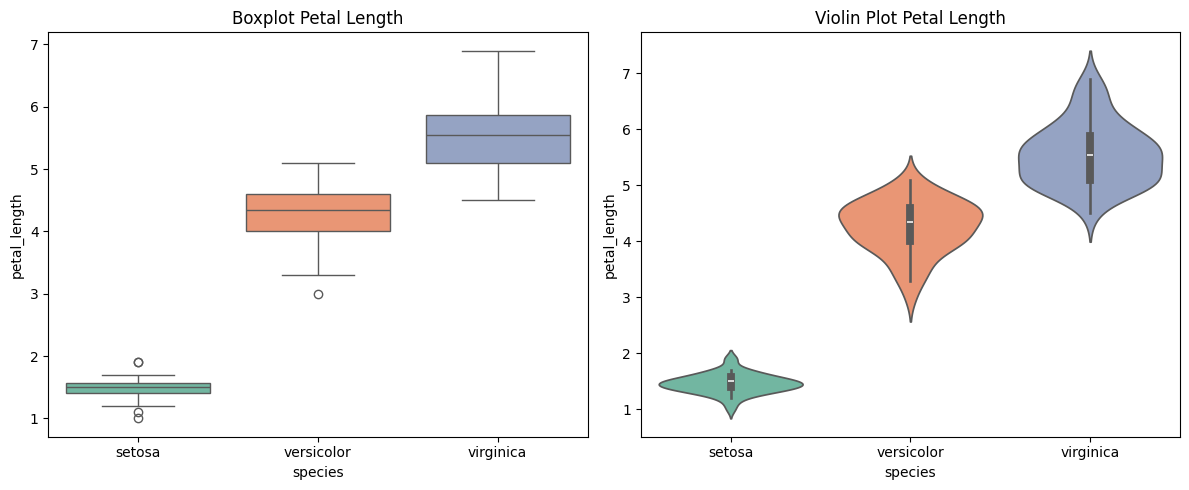

In [4]:
# 4. Boxplot per Spesies
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df,
            x='species',
            y='petal_length',
            hue='species',
            palette='Set2',
            ax=axes[0])

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(data=df,
               x='species',
               y='petal_length',
               hue='species',
               palette='Set2',
               inner='box',
               ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout(); plt.show()

In [5]:
# 5. Matriks Korelasi Pearson
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


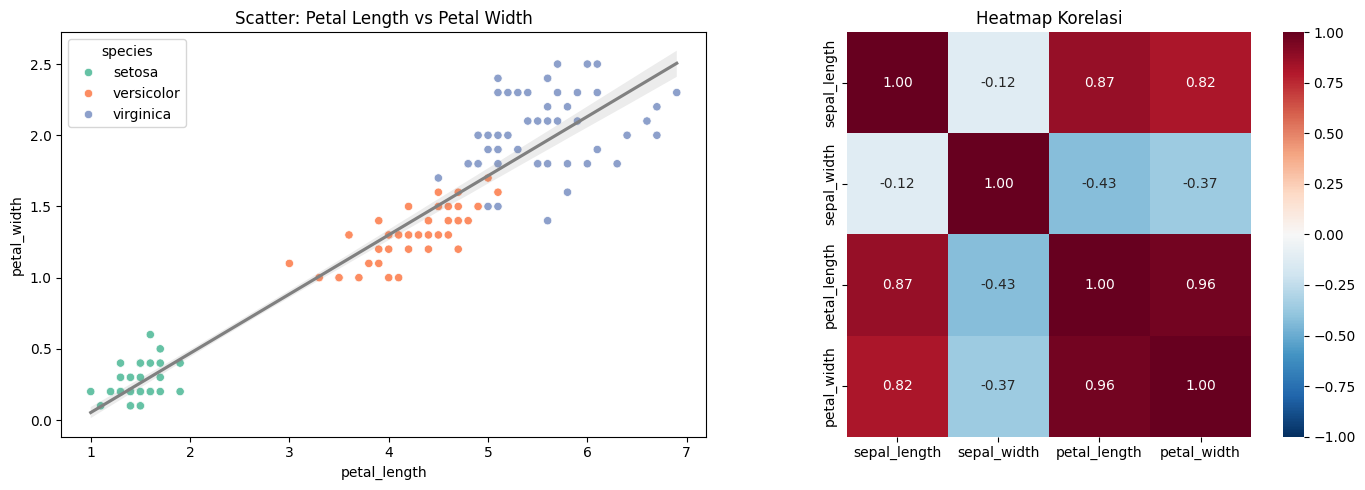

In [6]:
# 6. Scatter Plot & Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df,
                x='petal_length',
                y='petal_width',
                hue='species',
                palette='Set2',
                ax=axes[0])

sns.regplot(data=df,
            x='petal_length',
            y='petal_width',
            scatter=False,
            color='gray',
            ax=axes[0])

axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
vmin=-1, vmax=1, square=True, ax=axes[1])

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout(); plt.show()

**Kesimpulan**

---

Pada pertemuan 4 ini mempelajari cara melakukan analisis statistik deskriptif dan visualisasi data menggunakan Python, Pandas, Seaborn, dan Matplotlib pada dataset Iris. Analisis yang dilakukan meliputi pemeriksaan struktur dataset, perhitungan statistik deskriptif, analisis distribusi data, visualisasi boxplot dan violin plot, serta analisis korelasi antar variabel.


Hasil analisis menunjukkan bahwa dataset Iris terdiri dari 150 data dan 5 variabel, dengan 4 variabel numerik dan 1 variabel kategorikal (species). Berdasarkan statistik deskriptif, nilai rata-rata (mean) sepal length adalah 5,843 dan petal length adalah 3,758. Distribusi data pada sebagian besar variabel relatif mendekati normal karena nilai skewness berada di sekitar nol.

Visualisasi boxplot dan violin plot menunjukkan adanya perbedaan pada petal length antar spesies bunga. Selain itu, analisis korelasi menunjukkan bahwa hubungan paling kuat terdapat antara petal length dan petal width dengan nilai korelasi Pearson sebesar 0,963, yang menunjukkan hubungan positif sangat kuat. Sebaliknya, sepal width memiliki korelasi negatif lemah terhadap variabel lainnya.

Keterbatasan analisis ini adalah hanya menggunakan statistik deskriptif dan korelasi sehingga belum dapat menjelaskan hubungan sebab-akibat antar variabel.